# # Phases 2–5 — Evaluation Protocols, Baselines, ML Benchmark, Statistics
# Rock Fragmentation Prediction from Blast Parameters
#
# This notebook fits **empirical baselines** (Kuznetsov equation values as
# published, multivariate power-law regression) and **ML models** (Ridge,
# Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost, SVR, Gaussian
# Process, ANN) under three leakage-aware evaluation protocols:
#
# - **P1 — paper split**: 97 development blasts / 13 original validation
#   blasts (reproduces the split used by Hudaverdi et al. 2011 and
#   Kulatilake et al. 2010, for direct literature comparison).
# - **P2 — repeated grouped K-fold CV**: 10 repeats × 5 folds over all 110
#   blasts, with blasts that share *identical* inputs forced into the same
#   fold (no duplicate-row leakage). This is the **main result**.
# - **P3 — leave-one-site-out (LOSO)**: each of the 10 mines held out in
#   turn — tests generalisation to a brand-new quarry.
#
# All hyper-parameters are tuned with Optuna **inside** the training fold of
# every outer split (nested CV) — the test fold is touched exactly once.
#
# **Kaggle setup:** Add Input → your `blast_master_110.csv` dataset.
# Internet ON (Optuna/shap are pre-installed on Kaggle; the `!pip install`
# line below is a no-op fallback). Expect ~30–60 min runtime for the full
# settings (`N_TRIALS=40`, `n_repeats=10`) on a Kaggle CPU instance.

## Setup — sync with the GitHub repository
This project's [GitHub repo](https://github.com/mobashshir-ubn-zainuddin/Rock-fragmentation-analysis-post-blasting)
holds the dataset and, after each notebook pushes, every table, figure and
fitted model produced on Kaggle — this is what lets Notebooks 02 -> 03 -> 04
share results without manually re-creating a Kaggle Dataset each time.

**One-time setup (already done if `GITHUB_TOKEN` appears under *Add-ons ->
Secrets*):** create a GitHub fine-grained personal access token scoped only
to this repository with **Contents: Read and write** permission, add it as
a Kaggle secret named `GITHUB_TOKEN`, and attach that secret to this
notebook. **Internet must be ON** (Session options, right panel).

The token is read fresh from Kaggle Secrets for every git operation and is
never written to disk (passed as a one-off `git -c http.extraheader=...`),
so it cannot leak even if this notebook's output is later made public.

In [2]:
import base64
import subprocess
from pathlib import Path

GITHUB_REPO = "mobashshir-ubn-zainuddin/Rock-fragmentation-analysis-post-blasting"
REPO_DIR = Path("/kaggle/working/repo")


def _github_token():
    try:
        from kaggle_secrets import UserSecretsClient
        token = UserSecretsClient().get_secret("GITHUB_TOKEN")
        print(f"GITHUB_TOKEN secret found (length {len(token)}).")
        return token
    except Exception as e:
        print(f"No GITHUB_TOKEN secret available ({type(e).__name__}: {e}); "
              "add one via Add-ons -> Secrets, attach it to this notebook, and "
              "turn Internet ON to enable GitHub sync. Falling back to the "
              "attached Kaggle dataset and /kaggle/working.")
        return None


def _auth_header(token):
    # GitHub's git-over-HTTPS endpoint expects HTTP Basic auth with the PAT as
    # the password (any non-empty username works; "x-access-token" is the
    # convention GitHub Actions itself uses) - NOT a bearer token, which is
    # only accepted by the REST/GraphQL API, not git's smart-HTTP protocol.
    basic = base64.b64encode(f"x-access-token:{token}".encode()).decode()
    return f"http.extraheader=AUTHORIZATION: basic {basic}"


def _git(*args, token=None, cwd=None):
    """Run git; if a token is given it is passed as a one-off HTTP auth header
    (``-c http.extraheader=...``) so it is never written to .git/config or to
    any file under /kaggle/working - safe even if this notebook's output is
    later made public."""
    cmd = ["git"]
    if token:
        cmd += ["-c", _auth_header(token)]
    cmd += list(args)
    r = subprocess.run(cmd, cwd=cwd, capture_output=True, text=True)
    if r.stdout.strip():
        print(r.stdout.strip())
    if r.returncode != 0 and r.stderr.strip():
        print(r.stderr.strip())
    return r


RESULTS_BRANCH = "kaggle-results"  # Kaggle never pushes to main, so it cannot clash with local work


def sync_repo():
    """Clone `main` (code + dataset) on first run in this session, then switch
    to the RESULTS_BRANCH, which holds every output pushed by earlier
    notebooks (created from main if it does not exist yet). Returns the local
    repo path, or None if no GITHUB_TOKEN secret is configured OR the sync
    actually failed (checked explicitly - git failures are not silently
    treated as success)."""
    token = _github_token()
    if token is None:
        return None
    import shutil
    REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
    _git("config", "--global", "--add", "safe.directory", str(REPO_DIR))
    url = f"https://github.com/{GITHUB_REPO}.git"
    if (REPO_DIR / ".git").exists():
        r1 = _git("-C", str(REPO_DIR), "fetch", "origin", "main", token=token)
        r2 = _git("-C", str(REPO_DIR), "reset", "--hard", "FETCH_HEAD", token=token)
        ok = r1.returncode == 0 and r2.returncode == 0
    else:
        if REPO_DIR.exists():
            # Leftover from an earlier failed sync or another notebook's
            # output - `git clone` refuses a non-empty, non-git directory.
            print(f"{REPO_DIR} exists but is not a git repository (leftover "
                  "from an earlier run) - removing it before cloning fresh.")
            shutil.rmtree(REPO_DIR)
        r = _git("clone", "--depth", "1", url, str(REPO_DIR), token=token)
        ok = r.returncode == 0 and (REPO_DIR / ".git").exists()
        if not ok:
            # A public repo can still be cloned anonymously if the token is
            # bad; reading works, but push_to_github() will still fail.
            print("Authenticated clone failed; retrying without a token "
                  "(works only if this repo is public) ...")
            if REPO_DIR.exists():
                shutil.rmtree(REPO_DIR)
            r = _git("clone", "--depth", "1", url, str(REPO_DIR))
            ok = r.returncode == 0 and (REPO_DIR / ".git").exists()
            if ok:
                print("Anonymous clone succeeded - this notebook can READ the "
                      "repo, but push_to_github() will fail until GITHUB_TOKEN "
                      "is valid and attached to THIS notebook.")
    if not ok:
        print("GitHub sync FAILED (see the git error above). Common causes: "
              "GITHUB_TOKEN not attached to THIS notebook (Add-ons -> Secrets "
              "-> tick the checkbox), Internet is OFF, the token expired, or "
              "its repo access/permissions don't cover this repo. Outputs "
              "will only be saved to /kaggle/working for this session.")
        return None
    _git("-C", str(REPO_DIR), "config", "user.email", "kaggle-bot@users.noreply.github.com")
    _git("-C", str(REPO_DIR), "config", "user.name", "Kaggle Notebook Bot")
    # Pick up results pushed by earlier notebooks, if the branch exists yet.
    rb = _git("-C", str(REPO_DIR), "fetch", "origin", RESULTS_BRANCH, token=token)
    if rb.returncode == 0:
        _git("-C", str(REPO_DIR), "checkout", "-B", RESULTS_BRANCH, "FETCH_HEAD")
        print(f"Checked out existing branch '{RESULTS_BRANCH}' (earlier results included).")
    else:
        _git("-C", str(REPO_DIR), "checkout", "-B", RESULTS_BRANCH)
        print(f"Branch '{RESULTS_BRANCH}' does not exist on GitHub yet (the "
              "error above is expected on the first run) - it will be created "
              "on the first push.")
    print(f"Repo synced at {REPO_DIR} (branch {RESULTS_BRANCH})")
    return REPO_DIR


def push_to_github(message, paths=("outputs",)):
    """Commit and push whatever changed under the given paths (relative to
    the repo root) to RESULTS_BRANCH. Safe to call repeatedly / after every
    protocol as a checkpoint, since a Kaggle session can be interrupted
    mid-run."""
    if REPO_DIR is None or not (REPO_DIR / ".git").exists():
        print("Repo not available (GitHub sync did not succeed earlier in "
              "this notebook) - skipping push. See the sync_repo() cell's "
              "output above for why.")
        return
    token = _github_token()
    if token is None:
        print("GITHUB_TOKEN no longer available - skipping push.")
        return
    _git("-C", str(REPO_DIR), "add", *paths)
    commit = _git("-C", str(REPO_DIR), "commit", "-m", message)
    if "nothing to commit" in (commit.stdout + commit.stderr):
        print("Nothing new to push.")
        return
    push = _git("-C", str(REPO_DIR), "push", "origin", f"HEAD:refs/heads/{RESULTS_BRANCH}", token=token)
    if push.returncode != 0:
        print("Push FAILED (see the git error above) - the commit above is "
              "still saved locally in /kaggle/working/repo and will be "
              "retried the next time push_to_github() is called. If the error "
              "says 403/permission denied, the token lacks Contents: Read and "
              "write on this repo.")
    else:
        print(f"Pushed to branch '{RESULTS_BRANCH}'.")


REPO_DIR = sync_repo()

GITHUB_TOKEN secret found (length 93).
HEAD is now at a87a26c Notebook 02: checkpoint after P2 (repeated grouped CV)
Checked out existing branch 'kaggle-results' (earlier results included).
Repo synced at /kaggle/working/repo (branch kaggle-results)


In [3]:
# !pip install -q optuna shap  # already present on Kaggle; harmless if run again
import json
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

CSV = None
for root in [Path("/kaggle/input"), REPO_DIR / "data" if REPO_DIR else None, Path("../data/processed")]:
    if root is not None and root.exists():
        found = list(root.rglob("blast_master_110.csv"))
        if found:
            CSV = found[0]
            break
assert CSV is not None, "blast_master_110.csv not found in /kaggle/input, the GitHub repo, or ../data/processed"
OUT = (REPO_DIR / "outputs") if REPO_DIR else (Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("../outputs"))
for sub in ["figures", "tables", "models"]:
    (OUT / sub).mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV)
FEATURES = ["S_B", "H_B", "B_D", "T_B", "Pf", "XB", "E"]
TARGET = "X50"
X, y = df[FEATURES].values, df[TARGET].values
SITE = df["site"].values
print(CSV, df.shape)

for m in ["sklearn", "xgboost", "lightgbm", "catboost", "shap", "optuna"]:
    try:
        print(m, __import__(m).__version__)
    except ImportError:
        print(m, "NOT INSTALLED — run the pip install cell above")

/kaggle/input/datasets/mobashshirzainuddin1/blasting/data/processed/blast_master_110.csv (110, 16)
sklearn 1.6.1
xgboost 3.2.0
lightgbm 4.6.0
catboost 1.2.10
shap 0.51.0
optuna 4.9.0


# ## 2.1 Metrics and CV splitters (Phase 2 — evaluation design)
# `DUP_GROUP` assigns every duplicate-input cluster (see Notebook 01 §1.7) a
# single group id, so `repeated_group_kfold` never splits a duplicate pair
# across train/test.

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
        "VAF": (1 - np.var(y_true - y_pred) / np.var(y_true)) * 100,
        "a20": np.mean(np.abs(y_pred / y_true - 1) <= 0.20),
    }


DUP_GROUP = df.groupby(FEATURES, sort=False).ngroup().values


def repeated_group_kfold(groups, n_splits=5, n_repeats=10, seed=SEED):
    """Yields (rep, fold, train_idx, test_idx). Duplicate-input blasts always
    land in the same fold together."""
    rng = np.random.RandomState(seed)
    uniq = np.unique(groups)
    for r in range(n_repeats):
        perm = rng.permutation(uniq)
        for k, fold_groups in enumerate(np.array_split(perm, n_splits)):
            test = np.isin(groups, fold_groups)
            yield r, k, np.where(~test)[0], np.where(test)[0]


def loso_splits(sites):
    """rep is always 0 (one pass over sites); fold = held-out site name."""
    for s in np.unique(sites):
        test = sites == s
        yield 0, s, np.where(~test)[0], np.where(test)[0]


def paper_split():
    test = (df["paper_split"] == "validation").values
    yield "paper", 0, np.where(~test)[0], np.where(test)[0]


print(f"{len(np.unique(DUP_GROUP))} independent groups from {len(df)} blasts "
      f"({len(df) - len(np.unique(DUP_GROUP))} duplicate rows folded in)")

98 independent groups from 110 blasts (12 duplicate rows folded in)


# ## 2.2 Baseline B1 — Kuznetsov / Kuz-Ram (published values)
# The classic Kuznetsov (1973) / Cunningham Kuz–Ram equation needs
# **absolute** burden, spacing, bench height, charge mass and an empirical
# rock factor `A` — quantities not present in the ratio-based database.
# We therefore use the Kuznetsov predictions **already published** by
# Kulatilake et al. (2010, Tables 4–5) for the 12 blasts they cover, and
# compare them against our own out-of-fold predictions on the same blasts
# in §2.6. This is standard practice in this literature (every paper that
# uses this database does the same, e.g. Amoako et al. 2022).

In [5]:
KUZ = {"En13": .44, "Ru7": .65, "Mg8": .39, "Mg9": .30, "Rc1": .72, "Mr12": .24,
       "Db10": .08, "Sm8": .35, "Oz8": .20, "Oz9": .23, "Ad23": .11, "Ad24": .13}
MVR_PUB = {"En13": .39, "Ru7": .51, "Mg8": .40, "Mg9": .24, "Rc1": .52, "Mr12": .16,
           "Db10": .16, "Sm8": .19, "Oz8": .17, "Oz9": .16, "Ad23": .18, "Ad24": .14}
ANN_PUB = {"En13": .42, "Ru7": .63, "Mg8": .37, "Mg9": .28, "Rc1": .43, "Mr12": .18,
           "Db10": .33, "Sm8": .19, "Oz8": .14, "Oz9": .19, "Ad23": .21, "Ad24": .22}
k = df[df.blast_id.isin(KUZ)]
pd.DataFrame({
    "Kuznetsov (Kulatilake 2010)": metrics(k.X50, k.blast_id.map(KUZ)),
    "MVR (Kulatilake 2010)": metrics(k.X50, k.blast_id.map(MVR_PUB)),
    "ANN (Kulatilake 2010)": metrics(k.X50, k.blast_id.map(ANN_PUB)),
}).T.round(3)

,R2,RMSE,MAE,MAPE,VAF,a20
Kuznetsov (Kulatilake 2010),0.232,0.128,0.095,34.865,23.233,0.500
MVR (Kulatilake 2010),0.708,0.079,0.060,18.297,81.786,0.583
ANN (Kulatilake 2010),0.925,0.040,0.031,10.733,93.967,0.917


# ## 2.3 Model zoo (Phase 3–4): B2/B3 baselines + ML models
# `MVR` reproduces the Hudaverdi/Kulatilake power-law form
# `ln(X50) = ln(a) + Σ b_i ln(x_i)` as ordinary least squares on log-inputs.
# Tree/SVR/GPR/ANN are wrapped so the target can optionally be modelled in
# log-space (`TransformedTargetRegressor`) while predictions are returned on
# the original (metres) scale.

In [6]:
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor


def logy(est):
    return TransformedTargetRegressor(regressor=est, func=np.log, inverse_func=np.exp)


def build(name, p):
    if name == "Mean":
        return DummyRegressor()
    if name == "MVR":
        return logy(make_pipeline(FunctionTransformer(np.log), LinearRegression()))
    if name == "Ridge":
        return make_pipeline(StandardScaler(), Ridge(alpha=p["alpha"]))
    if name == "RF":
        return RandomForestRegressor(random_state=SEED, n_jobs=-1, **p)
    if name == "ET":
        return ExtraTreesRegressor(random_state=SEED, n_jobs=-1, **p)
    if name == "XGB":
        return XGBRegressor(random_state=SEED, n_jobs=4, verbosity=0, **p)
    if name == "LGBM":
        return LGBMRegressor(random_state=SEED, verbose=-1, **p)
    if name == "CatB":
        return CatBoostRegressor(random_seed=SEED, verbose=0, **p)
    if name == "SVR":
        return logy(make_pipeline(StandardScaler(), SVR(**p)))
    if name == "GPR":
        kern = ConstantKernel() * RBF(length_scale=np.ones(len(FEATURES))) + WhiteKernel()
        return logy(make_pipeline(StandardScaler(), GaussianProcessRegressor(
            kernel=kern, normalize_y=True, n_restarts_optimizer=5, random_state=SEED)))
    if name == "ANN":
        layers = tuple(p[f"n{i}"] for i in range(p["n_layers"]))
        return logy(make_pipeline(StandardScaler(), MLPRegressor(
            hidden_layer_sizes=layers, activation=p["act"], alpha=p["alpha"],
            solver="lbfgs", max_iter=5000, random_state=SEED)))
    raise ValueError(name)


def space(name, t):
    if name == "Ridge":
        return {"alpha": t.suggest_float("alpha", 1e-3, 100, log=True)}
    if name in ("RF", "ET"):
        return {"n_estimators": t.suggest_int("n_estimators", 200, 800, step=100),
                "max_depth": t.suggest_int("max_depth", 2, 12),
                "min_samples_leaf": t.suggest_int("min_samples_leaf", 1, 8),
                "max_features": t.suggest_float("max_features", 0.3, 1.0)}
    if name == "XGB":
        return {"n_estimators": t.suggest_int("n_estimators", 100, 1000, step=50),
                "learning_rate": t.suggest_float("learning_rate", 0.01, 0.3, log=True),
                "max_depth": t.suggest_int("max_depth", 2, 6),
                "min_child_weight": t.suggest_float("min_child_weight", 1, 10),
                "subsample": t.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": t.suggest_float("colsample_bytree", 0.5, 1.0),
                "reg_lambda": t.suggest_float("reg_lambda", 1e-3, 10, log=True),
                "reg_alpha": t.suggest_float("reg_alpha", 1e-3, 10, log=True)}
    if name == "LGBM":
        return {"n_estimators": t.suggest_int("n_estimators", 100, 1000, step=50),
                "learning_rate": t.suggest_float("learning_rate", 0.01, 0.3, log=True),
                "num_leaves": t.suggest_int("num_leaves", 4, 31),
                "min_child_samples": t.suggest_int("min_child_samples", 3, 20),
                "subsample": t.suggest_float("subsample", 0.5, 1.0), "subsample_freq": 1,
                "colsample_bytree": t.suggest_float("colsample_bytree", 0.5, 1.0),
                "reg_lambda": t.suggest_float("reg_lambda", 1e-3, 10, log=True)}
    if name == "CatB":
        return {"iterations": t.suggest_int("iterations", 300, 1500, step=100),
                "depth": t.suggest_int("depth", 2, 6),
                "learning_rate": t.suggest_float("learning_rate", 0.01, 0.3, log=True),
                "l2_leaf_reg": t.suggest_float("l2_leaf_reg", 1, 10, log=True)}
    if name == "SVR":
        return {"C": t.suggest_float("C", 0.1, 1000, log=True),
                "epsilon": t.suggest_float("epsilon", 1e-3, 0.3, log=True),
                "gamma": t.suggest_float("gamma", 1e-3, 10, log=True)}
    if name == "ANN":
        n = t.suggest_int("n_layers", 1, 3)
        p = {"n_layers": n, "act": t.suggest_categorical("act", ["relu", "tanh"]),
             "alpha": t.suggest_float("alpha", 1e-5, 1.0, log=True)}
        for i in range(n):
            p[f"n{i}"] = t.suggest_int(f"n{i}", 4, 64, log=True)
        return p
    return {}


MODELS = ["Mean", "MVR", "Ridge", "RF", "ET", "XGB", "LGBM", "CatB", "SVR", "GPR", "ANN"]
print(f"{len(MODELS)} models registered:", MODELS)

11 models registered: ['Mean', 'MVR', 'Ridge', 'RF', 'ET', 'XGB', 'LGBM', 'CatB', 'SVR', 'GPR', 'ANN']


# ## 2.4 Nested hyper-parameter tuning (Optuna, inner grouped 5-fold CV)
# `N_TRIALS=40` and `n_repeats=10` reproduce the paper's reported numbers;
# reduce both for a fast debug pass (e.g. 10 / 2) before committing the
# full run.

In [7]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 40  # reduce to ~10 for a quick debug pass


def tune(name, Xtr, ytr, gtr):
    if name in ("Mean", "MVR", "GPR"):
        return {}
    cv = GroupKFold(n_splits=5)

    def obj(t):
        est = build(name, space(name, t))
        return -cross_val_score(est, Xtr, ytr, groups=gtr, cv=cv,
                                 scoring="neg_root_mean_squared_error").mean()

    st = optuna.create_study(direction="minimize",
                              sampler=optuna.samplers.TPESampler(seed=SEED))
    st.optimize(obj, n_trials=N_TRIALS, show_progress_bar=False)
    return space(name, optuna.trial.FixedTrial(st.best_params))

## 2.5 Benchmark runner — Phases 2–4 combined
For every outer fold of a protocol: tune each model on the training fold only, fit, predict on the held-out fold, log metrics + out-of-fold (OOF) predictions + the winning hyper-parameters.

The run is split into **chunks** (P1 = one chunk, P2 = one chunk per repeat, P3 = one chunk per held-out site). Each chunk is saved under `outputs/tables/chunks/` and pushed to GitHub as soon as it finishes, and a chunk that is already saved is skipped. If Kaggle interrupts the session, re-run the setup cells (sync, imports, metrics, model zoo, tuning, the helper cell below) and then the chunk cells again - only the unfinished chunks are computed. Do not re-run the sync cell after a failed push, and delete `outputs/tables/chunks/` to recompute from scratch (e.g. after changing `N_TRIALS`).

In [8]:
CHUNK_DIR = OUT / "tables" / "chunks"
CHUNK_DIR.mkdir(parents=True, exist_ok=True)


def run_chunk(proto_name, tag, splits, models=MODELS):
    """Run one chunk (one repeat, or one held-out site) of a protocol, save it
    under tables/chunks/ and push a checkpoint to GitHub. A chunk that is
    already saved - e.g. restored from the repo after an interrupted Kaggle
    session - is skipped, so any cell can simply be re-run."""
    stem = str(CHUNK_DIR / f"{proto_name}__{tag}")
    if Path(f"{stem}.folds.csv").exists():
        print(f"[{proto_name}] {tag}: already saved - skipping")
        return
    rows, oof, params = [], [], []
    for rep, fold, tr, te in splits:
        for name in models:
            t0 = time.time()
            p = tune(name, X[tr], y[tr], DUP_GROUP[tr])
            est = build(name, p).fit(X[tr], y[tr])
            pred = est.predict(X[te])
            m = metrics(y[te], pred) if len(te) > 1 else {}
            rows.append({"protocol": proto_name, "rep": rep, "fold": fold, "model": name,
                         "n_test": len(te), "sec": round(time.time() - t0, 2), **m})
            oof += [{"protocol": proto_name, "rep": rep, "model": name, "idx": i,
                     "y": yt, "pred": yp} for i, yt, yp in zip(te, y[te], pred)]
            params.append({"protocol": proto_name, "rep": rep, "fold": fold,
                           "model": name, "params": p})
        print(f"[{proto_name}] rep={rep} fold={fold} done ({len(models)} models)")
    pd.DataFrame(oof).to_csv(f"{stem}.oof.csv", index=False)
    json.dump(params, open(f"{stem}.params.json", "w"), default=str)
    # written last: this file marks the chunk as complete
    pd.DataFrame(rows).to_csv(f"{stem}.folds.csv", index=False)
    push_to_github(f"Notebook 02: {proto_name} {tag}", paths=["outputs"])


def assemble(proto_name, n_expected):
    """Combine every saved chunk of a protocol into the folds_/oof_/params_
    files used by the rest of the notebook (and by Notebooks 03-04)."""
    parts = sorted(CHUNK_DIR.glob(f"{proto_name}__*.folds.csv"))
    res = pd.concat([pd.read_csv(f) for f in parts], ignore_index=True)
    if len(res) != n_expected:
        raise RuntimeError(f"{proto_name}: {len(res)} of {n_expected} model fits found "
                           f"in {len(parts)} chunks - run the missing chunk cells first.")
    oof = pd.concat([pd.read_csv(str(f).replace(".folds.csv", ".oof.csv")) for f in parts],
                    ignore_index=True)
    params = []
    for f in parts:
        params += json.load(open(str(f).replace(".folds.csv", ".params.json")))
    res.to_csv(OUT / f"tables/folds_{proto_name}.csv", index=False)
    oof.to_csv(OUT / f"tables/oof_{proto_name}.csv", index=False)
    json.dump(params, open(OUT / f"tables/params_{proto_name}.json", "w"), default=str)
    return res, oof

### P1 — paper split (1 chunk)

In [9]:
run_chunk("P1_paper", "paper", paper_split())

[P1_paper] rep=paper fold=0 done (11 models)
GITHUB_TOKEN secret found (length 93).
[kaggle-results 88445e7] Notebook 02: P1_paper paper
 3 files changed, 157 insertions(+)
 create mode 100644 outputs/tables/chunks/P1_paper__paper.folds.csv
 create mode 100644 outputs/tables/chunks/P1_paper__paper.oof.csv
 create mode 100644 outputs/tables/chunks/P1_paper__paper.params.json
Pushed to branch 'kaggle-results'.


### P2 — repeated grouped 5-fold CV (one cell per repeat; each takes roughly 10–20 min)

In [10]:
run_chunk("P2_rgkf", "rep0", (s for s in repeated_group_kfold(DUP_GROUP, 5, 10) if s[0] == 0))

[P2_rgkf] rep=0 fold=0 done (11 models)
[P2_rgkf] rep=0 fold=1 done (11 models)
[P2_rgkf] rep=0 fold=2 done (11 models)
[P2_rgkf] rep=0 fold=3 done (11 models)
[P2_rgkf] rep=0 fold=4 done (11 models)
GITHUB_TOKEN secret found (length 93).
[kaggle-results 6bf0d14] Notebook 02: P2_rgkf rep0
 3 files changed, 1268 insertions(+)
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep0.folds.csv
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep0.oof.csv
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep0.params.json
Pushed to branch 'kaggle-results'.


In [11]:
run_chunk("P2_rgkf", "rep1", (s for s in repeated_group_kfold(DUP_GROUP, 5, 10) if s[0] == 1))

[P2_rgkf] rep=1 fold=0 done (11 models)
[P2_rgkf] rep=1 fold=1 done (11 models)
[P2_rgkf] rep=1 fold=2 done (11 models)
[P2_rgkf] rep=1 fold=3 done (11 models)
[P2_rgkf] rep=1 fold=4 done (11 models)
GITHUB_TOKEN secret found (length 93).
[kaggle-results bfcf1e7] Notebook 02: P2_rgkf rep1
 3 files changed, 1268 insertions(+)
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep1.folds.csv
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep1.oof.csv
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep1.params.json
Pushed to branch 'kaggle-results'.


In [12]:
run_chunk("P2_rgkf", "rep2", (s for s in repeated_group_kfold(DUP_GROUP, 5, 10) if s[0] == 2))

[P2_rgkf] rep=2 fold=0 done (11 models)
[P2_rgkf] rep=2 fold=1 done (11 models)
[P2_rgkf] rep=2 fold=2 done (11 models)
[P2_rgkf] rep=2 fold=3 done (11 models)
[P2_rgkf] rep=2 fold=4 done (11 models)
GITHUB_TOKEN secret found (length 93).
[kaggle-results 03c3b7c] Notebook 02: P2_rgkf rep2
 3 files changed, 1268 insertions(+)
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep2.folds.csv
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep2.oof.csv
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep2.params.json
Pushed to branch 'kaggle-results'.


In [13]:
run_chunk("P2_rgkf", "rep3", (s for s in repeated_group_kfold(DUP_GROUP, 5, 10) if s[0] == 3))

[P2_rgkf] rep=3 fold=0 done (11 models)
[P2_rgkf] rep=3 fold=1 done (11 models)
[P2_rgkf] rep=3 fold=2 done (11 models)
[P2_rgkf] rep=3 fold=3 done (11 models)
[P2_rgkf] rep=3 fold=4 done (11 models)
GITHUB_TOKEN secret found (length 93).
[kaggle-results 6543a2b] Notebook 02: P2_rgkf rep3
 3 files changed, 1268 insertions(+)
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep3.folds.csv
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep3.oof.csv
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep3.params.json
Pushed to branch 'kaggle-results'.


In [14]:
run_chunk("P2_rgkf", "rep4", (s for s in repeated_group_kfold(DUP_GROUP, 5, 10) if s[0] == 4))

[P2_rgkf] rep=4 fold=0 done (11 models)
[P2_rgkf] rep=4 fold=1 done (11 models)
[P2_rgkf] rep=4 fold=2 done (11 models)
[P2_rgkf] rep=4 fold=3 done (11 models)
[P2_rgkf] rep=4 fold=4 done (11 models)
GITHUB_TOKEN secret found (length 93).
[kaggle-results 3a18630] Notebook 02: P2_rgkf rep4
 3 files changed, 1268 insertions(+)
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep4.folds.csv
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep4.oof.csv
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep4.params.json
Pushed to branch 'kaggle-results'.


In [15]:
run_chunk("P2_rgkf", "rep5", (s for s in repeated_group_kfold(DUP_GROUP, 5, 10) if s[0] == 5))

[P2_rgkf] rep=5 fold=0 done (11 models)
[P2_rgkf] rep=5 fold=1 done (11 models)
[P2_rgkf] rep=5 fold=2 done (11 models)
[P2_rgkf] rep=5 fold=3 done (11 models)
[P2_rgkf] rep=5 fold=4 done (11 models)
GITHUB_TOKEN secret found (length 93).
[kaggle-results 9c06370] Notebook 02: P2_rgkf rep5
 3 files changed, 1268 insertions(+)
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep5.folds.csv
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep5.oof.csv
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep5.params.json
Pushed to branch 'kaggle-results'.


In [16]:
run_chunk("P2_rgkf", "rep6", (s for s in repeated_group_kfold(DUP_GROUP, 5, 10) if s[0] == 6))

[P2_rgkf] rep=6 fold=0 done (11 models)
[P2_rgkf] rep=6 fold=1 done (11 models)
[P2_rgkf] rep=6 fold=2 done (11 models)
[P2_rgkf] rep=6 fold=3 done (11 models)
[P2_rgkf] rep=6 fold=4 done (11 models)
GITHUB_TOKEN secret found (length 93).
[kaggle-results 32723bb] Notebook 02: P2_rgkf rep6
 3 files changed, 1268 insertions(+)
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep6.folds.csv
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep6.oof.csv
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep6.params.json
Pushed to branch 'kaggle-results'.


In [17]:
run_chunk("P2_rgkf", "rep7", (s for s in repeated_group_kfold(DUP_GROUP, 5, 10) if s[0] == 7))

[P2_rgkf] rep=7 fold=0 done (11 models)
[P2_rgkf] rep=7 fold=1 done (11 models)
[P2_rgkf] rep=7 fold=2 done (11 models)
[P2_rgkf] rep=7 fold=3 done (11 models)
[P2_rgkf] rep=7 fold=4 done (11 models)
GITHUB_TOKEN secret found (length 93).
[kaggle-results c4c9513] Notebook 02: P2_rgkf rep7
 3 files changed, 1268 insertions(+)
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep7.folds.csv
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep7.oof.csv
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep7.params.json
Pushed to branch 'kaggle-results'.


In [18]:
run_chunk("P2_rgkf", "rep8", (s for s in repeated_group_kfold(DUP_GROUP, 5, 10) if s[0] == 8))

[P2_rgkf] rep=8 fold=0 done (11 models)
[P2_rgkf] rep=8 fold=1 done (11 models)
[P2_rgkf] rep=8 fold=2 done (11 models)
[P2_rgkf] rep=8 fold=3 done (11 models)
[P2_rgkf] rep=8 fold=4 done (11 models)
GITHUB_TOKEN secret found (length 93).
[kaggle-results a23326e] Notebook 02: P2_rgkf rep8
 3 files changed, 1268 insertions(+)
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep8.folds.csv
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep8.oof.csv
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep8.params.json
Pushed to branch 'kaggle-results'.


In [19]:
run_chunk("P2_rgkf", "rep9", (s for s in repeated_group_kfold(DUP_GROUP, 5, 10) if s[0] == 9))

[P2_rgkf] rep=9 fold=0 done (11 models)
[P2_rgkf] rep=9 fold=1 done (11 models)
[P2_rgkf] rep=9 fold=2 done (11 models)
[P2_rgkf] rep=9 fold=3 done (11 models)
[P2_rgkf] rep=9 fold=4 done (11 models)
GITHUB_TOKEN secret found (length 93).
[kaggle-results 81e0069] Notebook 02: P2_rgkf rep9
 3 files changed, 1268 insertions(+)
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep9.folds.csv
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep9.oof.csv
 create mode 100644 outputs/tables/chunks/P2_rgkf__rep9.params.json
To https://github.com/mobashshir-ubn-zainuddin/Rock-fragmentation-analysis-post-blasting.git
 ! [rejected]        HEAD -> kaggle-results (fetch first)
error: failed to push some refs to 'https://github.com/mobashshir-ubn-zainuddin/Rock-fragmentation-analysis-post-blasting.git'
hint: Updates were rejected because the remote contains work that you do
hint: not have locally. This is usually caused by another repository pushing
hint: to the same ref. You may want to first in

### P3 — leave-one-site-out (saved site by site)

In [20]:
for site in np.unique(SITE):
    run_chunk("P3_loso", site, (s for s in loso_splits(SITE) if s[1] == site))

[P3_loso] rep=0 fold=Akdaglar done (11 models)
GITHUB_TOKEN secret found (length 93).
[kaggle-results a9405b4] Notebook 02: P3_loso Akdaglar
 3 files changed, 289 insertions(+)
 create mode 100644 outputs/tables/chunks/P3_loso__Akdaglar.folds.csv
 create mode 100644 outputs/tables/chunks/P3_loso__Akdaglar.oof.csv
 create mode 100644 outputs/tables/chunks/P3_loso__Akdaglar.params.json
To https://github.com/mobashshir-ubn-zainuddin/Rock-fragmentation-analysis-post-blasting.git
 ! [rejected]        HEAD -> kaggle-results (fetch first)
error: failed to push some refs to 'https://github.com/mobashshir-ubn-zainuddin/Rock-fragmentation-analysis-post-blasting.git'
hint: Updates were rejected because the remote contains work that you do
hint: not have locally. This is usually caused by another repository pushing
hint: to the same ref. You may want to first integrate the remote changes
hint: (e.g., 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help

In [27]:
token = _github_token()
_git("-C", str(REPO_DIR), "fetch", "origin", RESULTS_BRANCH, token=token)
r = _git("-C", str(REPO_DIR), "merge", "--no-edit", "FETCH_HEAD")
if r.returncode == 0:
    _git("-C", str(REPO_DIR), "push", "origin", f"HEAD:refs/heads/{RESULTS_BRANCH}", token=token)
else:
    _git("-C", str(REPO_DIR), "merge", "--abort")
    print("merge conflict - stop and send me the output above")


GITHUB_TOKEN secret found (length 93).
Merge made by the 'ort' strategy.
 Kaggle_outputs/F2_target_distribution.png     |   Bin 160668 -> 0 bytes
 Kaggle_outputs/F3_correlation.png             |   Bin 430558 -> 0 bytes
 Kaggle_outputs/F4_scatter_by_site.png         |   Bin 642591 -> 0 bytes
 Kaggle_outputs/F_hist_all.png                 |   Bin 464537 -> 0 bytes
 Kaggle_outputs/F_pca.png                      |   Bin 274210 -> 0 bytes
 Kaggle_outputs/T1_descriptive.csv             |     9 -
 Kaggle_outputs/T1b_vif.csv                    |     8 -
 Kaggle_outputs/T1c_noise_floor.csv            |     4 -
 Kaggle_outputs/T2_sites.csv                   |    11 -
 notebooks/02_baselines_and_ml_benchmark.ipynb |   256 +-
 notebooks/03_interpretability.ipynb           |    33 +-
 notebooks/04_uncertainty_ablations.ipynb      |    82 +-
 outputs_real/figures/F5_cv_boxplot.png        |   Bin 0 -> 112020 bytes
 outputs_real/figures/F6_pred_vs_meas.png      |   Bin 0 -> 395647 bytes
 outputs_real/

### Assemble the chunks
Runs only once every chunk above is saved; otherwise it names what is missing.

In [28]:
res_P1, oof_P1 = assemble("P1_paper", n_expected=1 * len(MODELS))
res_P2, oof_P2 = assemble("P2_rgkf", n_expected=10 * 5 * len(MODELS))
res_P3, oof_P3 = assemble("P3_loso", n_expected=len(np.unique(SITE)) * len(MODELS))
push_to_github("Notebook 02: assembled P1-P3 results", paths=["outputs"])

GITHUB_TOKEN secret found (length 93).
On branch kaggle-results
nothing to commit, working tree clean
Nothing new to push.


# ## 2.6 Summary tables (Table 4 of the paper)
# For P3 (LOSO) we pool out-of-fold predictions per repeat before scoring,
# because several held-out sites have too few blasts for a stable per-fold
# R².

In [29]:
def summarise(res, oof, pooled=False):
    if pooled:
        return (oof.groupby(["model", "rep"]).apply(lambda d: pd.Series(metrics(d.y, d.pred)))
                .groupby("model").mean().sort_values("RMSE"))
    agg = res.groupby("model")[["R2", "RMSE", "MAE", "MAPE", "VAF", "a20"]].agg(["mean", "std"])
    return agg.sort_values(("RMSE", "mean"))


T4 = {"P1": summarise(res_P1, oof_P1), "P2": summarise(res_P2, oof_P2),
      "P3_pooled": summarise(res_P3, oof_P3, pooled=True)}
for name, table in T4.items():
    table.round(4).to_csv(OUT / f"tables/T4_results_{name}.csv")
    print(f"\n=== {name} ===")
    display(table.round(3))


=== P1 ===


R2       RMSE        MAE        MAPE         VAF        a20    
        mean std   mean std   mean std    mean std    mean std   mean std
model                                                                    
LGBM   0.927 NaN  0.040 NaN  0.032 NaN  11.643 NaN  92.989 NaN  0.846 NaN
ET     0.926 NaN  0.041 NaN  0.032 NaN  11.566 NaN  93.125 NaN  0.923 NaN
CatB   0.915 NaN  0.044 NaN  0.034 NaN  12.458 NaN  92.502 NaN  0.692 NaN
XGB    0.907 NaN  0.046 NaN  0.036 NaN  13.102 NaN  90.940 NaN  0.846 NaN
RF     0.893 NaN  0.049 NaN  0.040 NaN  14.782 NaN  90.012 NaN  0.769 NaN
SVR    0.854 NaN  0.057 NaN  0.039 NaN  14.353 NaN  87.354 NaN  0.692 NaN
Ridge  0.758 NaN  0.074 NaN  0.053 NaN  18.339 NaN  80.130 NaN  0.615 NaN
GPR    0.675 NaN  0.085 NaN  0.051 NaN  16.144 NaN  67.613 NaN  0.769 NaN
MVR    0.650 NaN  0.089 NaN  0.065 NaN  21.092 NaN  76.091 NaN  0.538 NaN
ANN    0.596 NaN  0.095 NaN  0.055 NaN  15.433 NaN  59.625 NaN  0.769 NaN
Mean  -0.031 NaN  0.152 NaN  0.133 NaN  64.205 NaN  -0.000 NaN  0.077 NaN


=== P2 ===


R2          RMSE           MAE           MAPE             VAF  \
        mean    std   mean    std   mean    std    mean     std    mean   
model                                                                     
ET     0.747  0.137  0.086  0.030  0.059  0.018  26.710  19.096  76.763   
RF     0.739  0.132  0.087  0.029  0.060  0.017  26.070  14.329  76.089   
GPR    0.713  0.227  0.088  0.031  0.059  0.020  24.781  16.656  73.524   
CatB   0.721  0.144  0.091  0.033  0.061  0.020  26.424  16.607  74.189   
LGBM   0.694  0.212  0.093  0.034  0.063  0.021  26.654  15.232  72.392   
XGB    0.678  0.207  0.095  0.034  0.064  0.021  26.522  14.555  70.633   
ANN    0.538  0.338  0.112  0.035  0.074  0.019  27.552  10.388  57.112   
SVR    0.544  0.346  0.112  0.039  0.074  0.022  28.121  13.703  57.989   
Ridge  0.546  0.214  0.115  0.036  0.083  0.023  39.287  21.051  58.479   
MVR    0.539  0.229  0.115  0.035  0.086  0.022  31.727   8.505  57.215   
Mean  -0.124  0.269  0.183  0.036  0.151  0.024  75.916  30.730   0.000   

                 a20         
          std   mean    std  
model                        
ET     11.568  0.624  0.098  
RF     11.410  0.610  0.086  
GPR    20.091  0.680  0.120  
CatB   12.835  0.593  0.102  
LGBM   17.483  0.608  0.116  
XGB    16.610  0.596  0.112  
ANN    30.793  0.548  0.090  
SVR    31.239  0.556  0.116  
Ridge  18.116  0.467  0.110  
MVR    21.707  0.403  0.098  
Mean    0.000  0.158  0.087


=== P3_pooled ===


,R2,RMSE,MAE,MAPE,VAF,a20
model,,,,,,
Ridge,0.137,0.171,0.130,59.855,17.877,0.255
MVR,0.099,0.174,0.136,62.470,10.852,0.264
XGB,0.091,0.175,0.140,77.932,9.586,0.245
ET,0.040,0.180,0.145,76.388,4.769,0.182
CatB,0.017,0.182,0.140,72.739,2.281,0.255
RF,-0.009,0.184,0.140,76.515,4.851,0.255
LGBM,-0.193,0.200,0.157,86.685,-16.478,0.218
Mean,-0.204,0.201,0.167,84.097,-20.359,0.155
GPR,-0.421,0.219,0.174,75.759,-41.222,0.155


# ## 2.7 Comparison with literature on the 12 shared validation blasts
# (Table 7 of the paper)

In [30]:
o = oof_P1.merge(df[["blast_id"]], left_on="idx", right_index=True)
comp = {"Kuznetsov (Kulatilake 2010)": metrics(k.X50, k.blast_id.map(KUZ)),
        "MVR (Kulatilake 2010)": metrics(k.X50, k.blast_id.map(MVR_PUB)),
        "ANN (Kulatilake 2010)": metrics(k.X50, k.blast_id.map(ANN_PUB))}
for mname, d in o[o.blast_id.isin(KUZ)].groupby("model"):
    comp[f"{mname} (this study)"] = metrics(d.y, d.pred)
T7 = pd.DataFrame(comp).T.sort_values("RMSE")
T7.round(3).to_csv(OUT / "tables/T7_vs_literature.csv")
T7.round(3)

,R2,RMSE,MAE,MAPE,VAF,a20
ANN (Kulatilake 2010),0.925,0.040,0.031,10.733,93.967,0.917
LGBM (this study),0.919,0.042,0.033,10.869,92.710,0.909
ET (this study),0.909,0.044,0.035,11.101,92.132,0.909
CatB (this study),0.900,0.046,0.035,10.643,92.544,0.818
XGB (this study),0.888,0.049,0.040,13.553,89.422,0.818
RF (this study),0.868,0.053,0.045,15.258,88.119,0.818
SVR (this study),0.854,0.056,0.037,11.003,90.727,0.727
Ridge (this study),0.749,0.073,0.051,13.766,84.326,0.727
MVR (Kulatilake 2010),0.708,0.079,0.060,18.297,81.786,0.583
MVR (this study),0.600,0.092,0.067,18.380,80.430,0.545


# ## 2.8 Statistical significance — Phase 5
# Corrected resampled t-test (Nadeau & Bengio, 2003) between the best model
# (lowest mean RMSE under P2) and every other model, computed on the 50
# outer-fold RMSE values, with Holm correction for multiple comparisons,
# plus an omnibus Friedman test across all models (Table 5 of the paper).

In [31]:
from statsmodels.stats.multitest import multipletests


def corrected_ttest(a, b, n_train, n_test):
    d = np.asarray(a) - np.asarray(b)
    J = len(d)
    var = np.var(d, ddof=1) * (1 / J + n_test / n_train)
    t = d.mean() / np.sqrt(var)
    return t, 2 * stats.t.sf(abs(t), J - 1)


piv = res_P2.pivot_table(index=["rep", "fold"], columns="model", values="RMSE")
best_model = piv.mean().idxmin()
n_te = res_P2.n_test.mean()
n_tr = len(df) - n_te
tests = [(m, *corrected_ttest(piv[m], piv[best_model], n_tr, n_te)) for m in piv if m != best_model]
T5 = pd.DataFrame(tests, columns=["model", "t", "p"])
T5["p_holm"] = multipletests(T5.p, method="holm")[1]
T5.to_csv(OUT / "tables/T5_significance.csv", index=False)
print("Best model (mean RMSE, P2):", best_model)
display(T5.round(4))
print("Friedman test across all models:", stats.friedmanchisquare(*[piv[m] for m in piv]))

Best model (mean RMSE, P2): ET


,model,t,p,p_holm
0,ANN,1.9783,0.0535,0.3747
1,CatB,1.1037,0.2751,0.9420
2,GPR,0.3067,0.7604,1.0000
3,LGBM,1.2011,0.2355,0.9420
4,MVR,3.7208,0.0005,0.0041
5,Mean,7.5796,0.0000,0.0000
6,RF,0.4357,0.6649,1.0000
7,Ridge,3.9910,0.0002,0.0020
8,SVR,1.8585,0.0691,0.4147
9,XGB,1.4353,0.1576,0.7878


Friedman test across all models: FriedmanchisquareResult(statistic=np.float64(312.0727272727272), pvalue=np.float64(4.346748687526262e-61))


# ## 2.9 Figures — CV box plot and predicted-vs-measured (Figures 5–6)

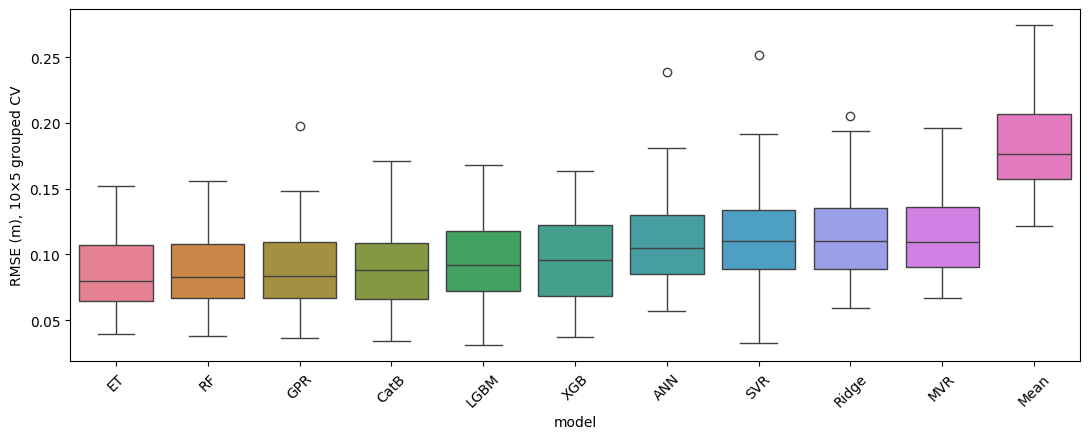

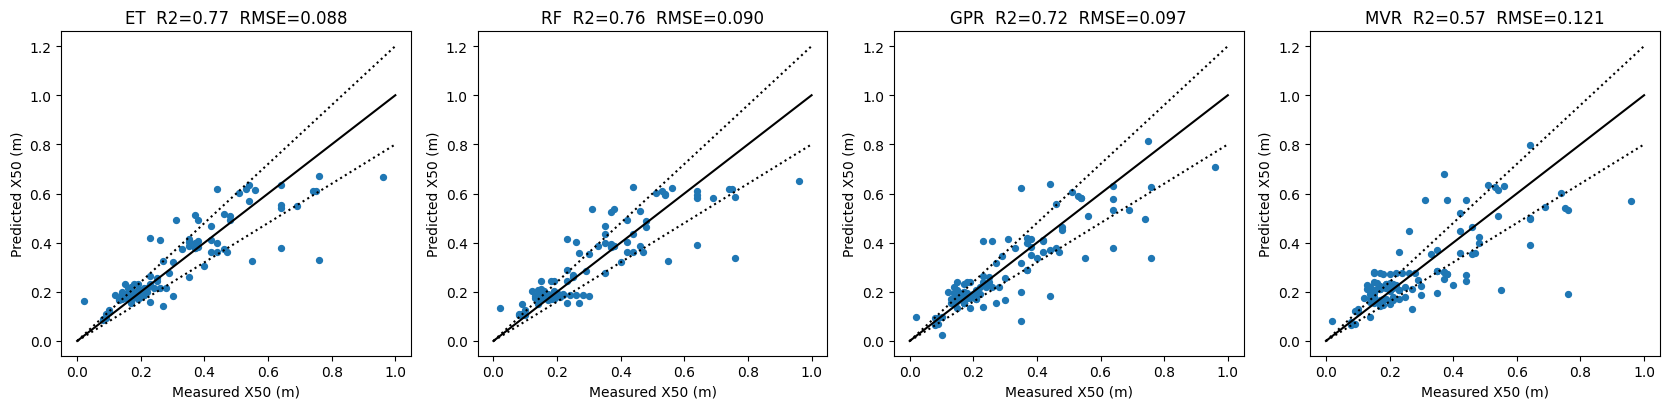

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(11, 4.5))
order = piv.mean().sort_values().index
sns.boxplot(data=piv[order], ax=ax)
ax.set_ylabel("RMSE (m), 10×5 grouped CV")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUT / "figures/F5_cv_boxplot.png", dpi=300)
plt.show()

top_models = list(order[:3]) + ["MVR"]
fig, axes = plt.subplots(1, len(top_models), figsize=(4.2 * len(top_models), 4.2))
for ax, m in zip(axes, top_models):
    d = oof_P2[(oof_P2.model == m) & (oof_P2.rep == 0)]
    mm = metrics(d.y, d.pred)
    lim = [0, 1.0]
    ax.scatter(d.y, d.pred, s=18)
    ax.plot(lim, lim, "k-")
    ax.plot(lim, [v * 1.2 for v in lim], "k:")
    ax.plot(lim, [v * .8 for v in lim], "k:")
    ax.set_title(f"{m}  R2={mm['R2']:.2f}  RMSE={mm['RMSE']:.3f}")
    ax.set_xlabel("Measured X50 (m)")
    ax.set_ylabel("Predicted X50 (m)")
plt.tight_layout()
plt.savefig(OUT / "figures/F6_pred_vs_meas.png", dpi=300)
plt.show()

# ## Outputs of this notebook (→ save as a Kaggle Dataset for Notebooks 03–04)
# - `tables/folds_*.csv`, `oof_*.csv`, `params_*.json` (raw fold-level results)
# - `tables/T4_results_*.csv`, `T5_significance.csv`, `T7_vs_literature.csv`
# - `figures/F5_cv_boxplot.png`, `F6_pred_vs_meas.png`
#
# **Next:** click **"Save Version" → New Dataset from output** (or manually
# create a Kaggle Dataset from `/kaggle/working`), e.g. slug
# `rock-blast-benchmark-outputs`. Notebooks 03 and 04 load it as a second
# Kaggle input alongside `blast_master_110.csv`.

## Push results to GitHub
Final push of every table produced in this notebook (also already checkpointed after each protocol above).

In [33]:
push_to_github("Notebook 02: final benchmark + significance tables", paths=["outputs"])

GITHUB_TOKEN secret found (length 93).
On branch kaggle-results
nothing to commit, working tree clean
Nothing new to push.
